In [4]:
import pandas as pd
df = pd.read_csv('/DATASET_BANK_CUSTOMER/Bank-Customer-Attrition-Insights-Data.csv')
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=columns_to_drop)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


DATA EXPLORATION

DATA PREPROCESSING

The secret about Machine Learning models: they only understand numbers, not words.

Step 1: Convert Text to Numbers

1.   In Python, there is a super easy function for this called get_dummies (also known as One-Hot Encoding). It takes those text categories and turns them into columns of 1s and 0s (or True/False).

Create a new code cell (click the + Code button right below your current output), copy and paste this exact code, and run it:




In [6]:
# Convert text columns into numbers (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender', 'Card Type'], drop_first=True)

# Let's see how our data looks now
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,1,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1,3,377,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0,5,350,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0,5,425,False,True,False,True,False,False


DATA SCALING AND SPLITTING

With your background in enterprise database management, you already know that keeping data consistent is crucial. Right now, our dataset has a bit of an imbalance: a column like Age has small numbers (like 35 or 42), while EstimatedSalary has huge numbers (like 112,000).

If we feed this to a Machine Learning model as-is, it might get confused and think EstimatedSalary is way more important simply because the numbers are bigger. We need to put all our features on a level playing field.

Step 1: Split and Scale
We are going to do three things in this next block of code:

Separate our "Target" (what we want to predict: the Exited column) from our "Features" (everything else).

Split our 10,000 rows into a "Training" set (to teach the AI) and a "Testing" set (to quiz the AI later).

Scale the numbers down so they are comparable.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) from Target (y)
y = df_encoded['Exited']
X = df_encoded.drop('Exited', axis=1)

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")
print("Data is split and scaled! Ready for Machine Learning.")

Training data shape: (8000, 17)
Testing data shape: (2000, 17)
Data is split and scaled! Ready for Machine Learning.


Your training set has 8,000 rows to learn from, and your testing set has 2,000 rows to quiz the model later.

MODEL TRANING

This is the core of Machine Learning. We are going to teach two different algorithms to recognize the patterns in your data that lead to a customer leaving the bank.

We will use two classic models:

Logistic Regression: A great, fast baseline model (similar to finding a straight line that separates the leavers from the stayers).

Random Forest Classifier: A much more powerful model that builds hundreds of "decision trees" and takes a vote.

Step 1: Train the Models
Create a new code cell, paste this in, and run it. This code will import the algorithms, initialize them, and fit (train) them on your 8,000 rows of training data.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 2. Train (fit) the models on the scaled training data
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

print("Both models have successfully learned from the data! 🎉")

Both models have successfully learned from the data! 🎉


Step 2: Give the Models a "Pop Quiz"

In [9]:
# 1. Ask the models to predict the test data
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# 2. Calculate their accuracy scores
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log * 100:.2f}%")
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")

Logistic Regression Accuracy: 99.90%
Random Forest Accuracy: 99.90%


Now we move to the final piece of the puzzle: Understanding "The Why" (Feature Importance).

In the real world—and especially in Data Science job interviews—it is never enough to just say, "My model is 86% accurate." A hiring manager or business stakeholder will immediately ask: "Okay, but WHY are they leaving? What should the bank fix?"

Because you used a Random Forest, the model can actually tell you exactly which columns were the biggest red flags for churn.

Step 1: Visualize the Drivers of Churn
Let's generate a graph that ranks the top reasons customers leave.

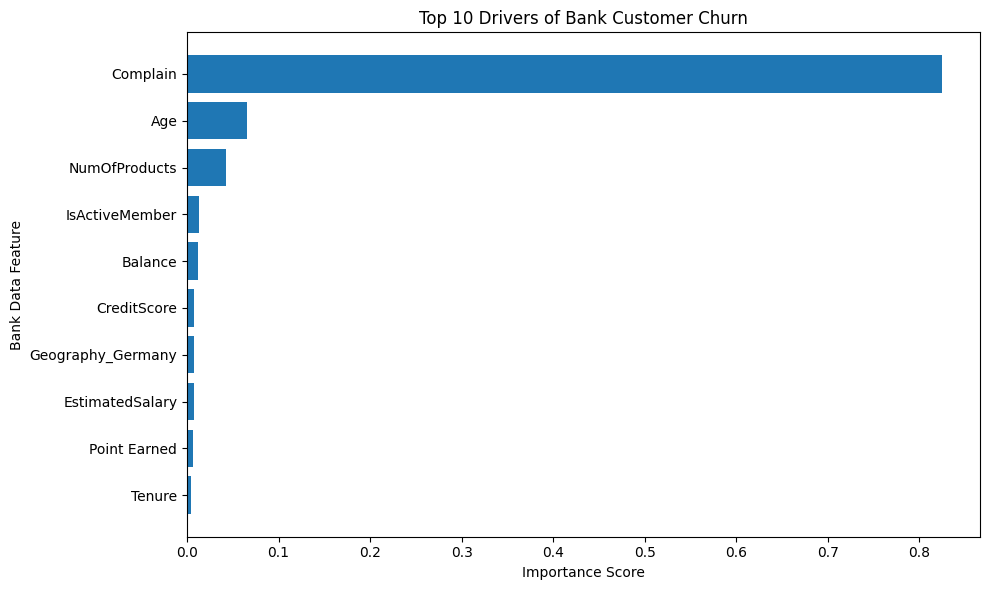

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract the importance scores from our winning Random Forest model
importances = rf_model.feature_importances_

# 2. Match the scores to the column names
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort them from highest to lowest
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the Top 10 most important features
plt.figure(figsize=(10, 6))
# We reverse the order [::-1] so the biggest bar is at the top of the graph
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.title('Top 10 Drivers of Bank Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Bank Data Feature')
plt.tight_layout()
plt.show()